# Representing JAX Device Mesh Sharding with CuTe Layouts

JAX's `jax.make_mesh` creates a device mesh by reshaping physical devices into a logical grid.
When the physical device topology doesn't match a simple linear order, the resulting mesh
has a non-trivial device-ID mapping. We can represent this exactly using CuTe's `Swizzle` + `Layout`.

## The JAX setup

```python
mesh = jax.make_mesh((4, 2), ('a', 'b'))
y = jax.device_put(x, NamedSharding(mesh, P('a', 'b')))
jax.debug.visualize_array_sharding(y)
```

```
┌──────────┬──────────┐
│  TPU 0   │  TPU 1   │
├──────────┼──────────┤
│  TPU 2   │  TPU 3   │
├──────────┼──────────┤
│  TPU 6   │  TPU 7   │
├──────────┼──────────┤
│  TPU 4   │  TPU 5   │
└──────────┴──────────┘
```

Notice the device IDs aren't in simple row-major order: rows 2 and 3 are swapped (6,7 before 4,5).
This reflects the physical TPU interconnect topology.

## Step 1: Row-major baseline

A plain 4x2 row-major layout maps `(i,j) -> 2i + j`, giving device IDs 0,1,2,3,4,5,6,7 in order.

(4, 2) : (2, 1)


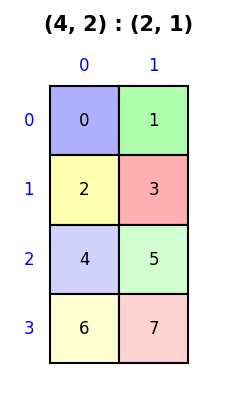

In [1]:
from tensor_layouts import Layout, Swizzle, compose
from tensor_layouts.viz import draw_layout

row_major = Layout((4, 2), (2, 1))
print(row_major)
draw_layout(row_major, colorize=True)

## Step 2: The topology permutation as a Swizzle

The physical device order is `[0, 1, 2, 3, 6, 7, 4, 5]` — for devices 4-7, bit 1 is flipped.
In binary:

| Position | Binary | Device | Binary | XOR |
|----------|--------|--------|--------|-----|
| 0 | 000 | 0 | 000 | — |
| 1 | 001 | 1 | 001 | — |
| 2 | 010 | 2 | 010 | — |
| 3 | 011 | 3 | 011 | — |
| 4 | **1**00 | 6 | **1**10 | bit 2 XORed into bit 1 |
| 5 | **1**01 | 7 | **1**11 | bit 2 XORed into bit 1 |
| 6 | **1**10 | 4 | **1**00 | bit 2 XORed into bit 1 |
| 7 | **1**11 | 5 | **1**01 | bit 2 XORed into bit 1 |

This is exactly `Swizzle(bits=1, base=1, shift=1)`: XOR 1 bit starting at position `base=1` with the bit at `base+shift=2`.

In [2]:
sw = Swizzle(1, 1, 1)
print("Swizzle permutation:")
for i in range(8):
    print(f"  {i} -> {sw(i)}")

Swizzle permutation:
  0 -> 0
  1 -> 1
  2 -> 2
  3 -> 3
  4 -> 6
  5 -> 7
  6 -> 4
  7 -> 5


## Step 3: Compose to get the mesh layout

Composing the swizzle with the row-major layout gives us the full device mesh mapping:

`mesh(i, j) = Swizzle(row_major(i, j))`

In [3]:
mesh_layout = compose(Swizzle(1, 1, 1), Layout((4, 2), (2, 1)))
print(mesh_layout)
print()

for i in range(4):
    row = [f"TPU {mesh_layout(i, j)}" for j in range(2)]
    print(f"  row {i}: {row}")

(Swizzle(1, 1, 1)) o ((4, 2) : (2, 1))

  row 0: ['TPU 0', 'TPU 1']
  row 1: ['TPU 2', 'TPU 3']
  row 2: ['TPU 6', 'TPU 7']
  row 3: ['TPU 4', 'TPU 5']


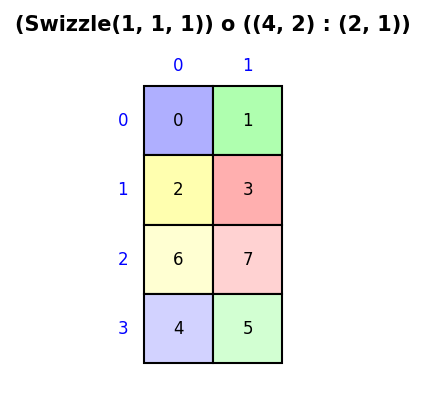

In [4]:
draw_layout(mesh_layout, colorize=True)

The visualization shows the same 4x2 grid with device IDs matching the JAX output:
TPUs 0,1 / 2,3 / 6,7 / 4,5 — the topology-aware ordering captured entirely
by a single `Swizzle` composed with a standard row-major layout.